#### Build a Simple Agent2Agent With LangGraph

In [66]:
# Import Packages
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage # AnyMessage can be (AIMessage, HumanMessage, UserMessage, ...)
from typing_extensions import TypedDict, Literal # type that we can use it in State
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from pprint import pprint

In [56]:
# Define State For Our Graph - Here We Define Historic
class ClientState(TypedDict):
    messages: list[AnyMessage]
    counter: int

In [57]:
# Define Node - Agentic Function - This Function
def node(state: ClientState):
    messages = state["messages"]
    print("Messages That We Have in States Are: ", state)
    new_messages = [AIMessage("Hello !")]
    return {"messages": messages + new_messages, "counter": state["counter"] + 1}

In [58]:
# Create Graph
workflow = StateGraph(ClientState)
workflow.add_node("Extracter_Agent", node)
workflow.add_edge(START, "Extracter_Agent")
workflow.add_edge("Extracter_Agent", END)

In [59]:
# compile take also (memory, wait for human validation, ...)
graph = workflow.compile()

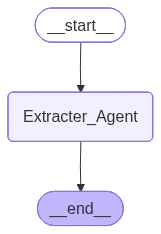

In [60]:
# Display Graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Execute Graph
initial_state = {"messages": [HumanMessage("Hi")], "counter": 0}
result = graph.invoke(initial_state)
pprint(result)

Messages That We Have in States Are:  {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})], 'counter': 0}
{'counter': 1,
 'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
              AIMessage(content='Hello !', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}


### Simple Agent for Anaylse documents

In [69]:
# Define state of agent
class EmployeeState(TypedDict):
    name: str
    age: int
    salary: float
    decision: Literal["standard_hr", "forced_hr"]
    result: str

In [ ]:
# Verfication Node
def analyze_employee(state: EmployeeState) -> EmployeeState:
    age = state["age"]
    salary = state["salary"]
    if (age <= 30 and salary <= 40000):
        state["decision"] = "standard_hr"
    else:
        state["decision"] = "forced_hr"
    return state

In [74]:
# Path 1 - Age <= 30 and Salary <= 40000
def standard_hr_process(state: EmployeeState):
    state["result"] = f"""Demand to {state["name"]} to send RH Standard the Document"""
    return state

In [73]:
# Path 2
def forced_hr_process(state: EmployeeState):
    state["result"] = f"""Demand to {state["name"]} to send RH Forced the Document"""
    return state

In [83]:
# Conditionnel Routing Function
def router(state: EmployeeState):
    return state['decision']

In [93]:
# Create Graph With EmployeeState
hr_workflow = StateGraph(EmployeeState)

# Add Node
hr_workflow.add_node("Anaylze_Employee", analyze_employee)
hr_workflow.add_node("Standard_RH_Process", standard_hr_process)
hr_workflow.add_node("Forced_RH_Process", forced_hr_process)

# Create Edge
hr_workflow.add_edge(START, "Anaylze_Employee")
hr_workflow.add_conditional_edges("Anaylze_Employee", 
    router, 
    {
        "standard_hr": "Standard_RH_Process",
        "forced_hr": "Forced_RH_Process"
    }
)

hr_workflow.add_edge("Standard_RH_Process", END)
hr_workflow.add_edge("Forced_RH_Process", END)

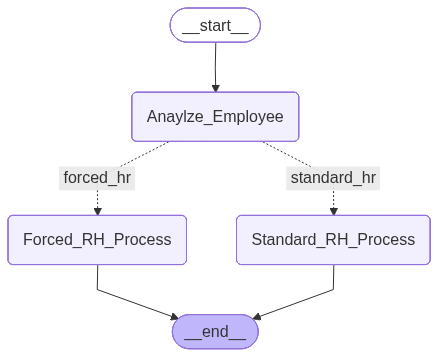

In [94]:
# Display The Graph
graph = hr_workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [95]:
# Execute Graph
initial_state = {"name": "abdellah", "age": 20, "salary": 90000}
result = graph.invoke(initial_state)
pprint(result)

{'age': 20,
 'decision': 'forced_hr',
 'name': 'abdellah',
 'result': 'Demand to abdellah to send RH Forced the Document',
 'salary': 90000}
